# Comparing Fréchet Means of SPD Matrices

Symmetric positive-definite (SPD) matrices appear as covariance matrices,
diffusion tensors, and kernel matrices. There is no single distinguished
Riemannian metric on the SPD cone, so a Fréchet mean depends on the geometry
chosen for the application.

For observations $P_1,\ldots,P_N$ and a distance $d_g$ induced by geometry
$g$, the Fréchet objective is

$$
F_g(P)=\frac{1}{2N}\sum_{i=1}^N d_g(P,P_i)^2.
$$

We compare three common choices:

| Geometry | Distance |
|---|---|
| Log-Euclidean | $\lVert\log P-\log Q\rVert_F$ |
| Affine-invariant | $\lVert\log(P^{-1/2}QP^{-1/2})\rVert_F$ |
| Bures-Wasserstein | $\bigl[\operatorname{tr}P+\operatorname{tr}Q-2\operatorname{tr}(P^{1/2}QP^{1/2})^{1/2}\bigr]^{1/2}$ |

The log-Euclidean metric is flat in matrix-logarithm coordinates. Its mean has
the closed form

$$
\bar P_{\mathrm{LE}}
=\exp\left(\frac1N\sum_{i=1}^N\log P_i\right).
$$

The other two means generally require iteration. The affine-invariant metric
is invariant under arbitrary invertible congruences, while the
Bures-Wasserstein metric is the covariance component of quadratic optimal
transport between centered Gaussian distributions.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

from geojax.geometry import (
    SPDAffineInvariant,
    SPDBuresWasserstein,
    SPDLogEuclidean,
)
from geojax.optimization import BarzilaiBorwein, Minimize

## Construct covariance observations

We use $2\times2$ covariance matrices so that every observation and estimate
can be drawn as an ellipse. The directions of the ellipse are the eigenvectors
of the covariance, and its semiaxis lengths are the square roots of the
eigenvalues.

The observations deliberately combine pronounced anisotropy with changing
orientations. If all matrices commuted, several geometric differences would
be much harder to see.

In [2]:
def rotation(theta):
    cosine, sine = jnp.cos(theta), jnp.sin(theta)
    return jnp.array([[cosine, -sine], [sine, cosine]])


def covariance(theta, eigenvalues):
    basis = rotation(theta)
    return basis @ jnp.diag(jnp.asarray(eigenvalues)) @ basis.T


samples = jnp.stack(
    [
        covariance(-1.05, (4.8, 0.25)),
        covariance(-0.62, (3.4, 0.40)),
        covariance(-0.15, (2.5, 0.70)),
        covariance(0.35, (1.8, 0.55)),
        covariance(0.78, (3.8, 0.30)),
        covariance(1.12, (5.2, 0.22)),
    ]
)

geometries = {
    "Log-Euclidean": SPDLogEuclidean(size=(2, 2)),
    "Affine-invariant": SPDAffineInvariant(size=(2, 2)),
    "Bures-Wasserstein": SPDBuresWasserstein(size=(2, 2)),
}

print("Number of observations:", len(samples))
for name, geometry in geometries.items():
    valid = jax.vmap(geometry.belongs)(samples)
    print(f"{name:20s}: all observations valid = {bool(jnp.all(valid))}")

Number of observations: 6
Log-Euclidean       : all observations valid = True
Affine-invariant    : all observations valid = True
Bures-Wasserstein   : all observations valid = True


Log-Euclidean       : all observations valid = True
Affine-invariant    : all observations valid = True
Bures-Wasserstein   : all observations valid = True


## Solve one Fréchet problem per geometry

The code below is intentionally geometry-agnostic. Only the object passed as
`M` changes; `dist_batch` and the optimizer consume the common GeoJAX
interface. All three runs start from the arithmetic mean and use the same
solver settings.

The objective values should not be compared directly across rows because the
three metrics use different units. The estimates, eigenvalues, determinants,
and convergence histories are directly informative.

In [3]:
def make_frechet_cost(geometry, observations):
    def cost(P):
        squared_distances = geometry.dist_batch(P, observations) ** 2
        return 0.5 * jnp.mean(squared_distances)

    return cost


initial = jnp.mean(samples, axis=0)
estimates = {}
histories = {}
final_costs = {}

for name, geometry in geometries.items():
    problem = Minimize(
        M=geometry,
        cost=make_frechet_cost(geometry, samples),
        x0=initial,
        solver=BarzilaiBorwein(
            initial_stepsize=0.5,
            maxiter=120,
            tolgradnorm=1e-9,
            verbosity=0,
        ),
    )
    estimate, final_cost, history = problem.solve()
    estimates[name] = estimate
    histories[name] = history
    final_costs[name] = final_cost

print(
    f"{'geometry':20s} {'iter':>5s} {'cost':>12s} "
    f"{'grad norm':>12s} {'det(mean)':>12s}"
)
print("-" * 68)
for name in geometries:
    history = histories[name]
    print(
        f"{name:20s} {history[-1].iter:5d} {final_costs[name]:12.6f} "
        f"{history[-1].gradnorm:12.3e} {float(jnp.linalg.det(estimates[name])):12.6f}"
    )

geometry              iter         cost    grad norm    det(mean)
--------------------------------------------------------------------
Log-Euclidean            2     1.366771    1.354e-15     1.242951
Affine-invariant         7     1.367706    8.525e-10     1.242951
Bures-Wasserstein        7     0.446111    3.566e-10     2.376709


## Validate the log-Euclidean result

The closed-form log-Euclidean mean gives an independent check of the numerical
optimization.

In [4]:
log_geometry = geometries["Log-Euclidean"]
log_samples = jax.vmap(log_geometry.logm)(samples)
closed_form = log_geometry.expm(jnp.mean(log_samples, axis=0))
closed_form_error = jnp.linalg.norm(estimates["Log-Euclidean"] - closed_form)

print("Closed-form log-Euclidean mean:\n", closed_form)
print(f"Optimization error: {float(closed_form_error):.3e}")

Closed-form log-Euclidean mean:
 [[1.06239834 0.07742265]
 [0.07742265 1.17559048]]
Optimization error: 1.857e-15


## Visual comparison

The arithmetic mean is included as a Euclidean baseline. The bottom-right
panel puts all solver histories on a common logarithmic gradient scale. The
Bures-Wasserstein ellipse is expected to be larger here: that geometry averages
covariance square roots through an optimal-transport construction, whereas the
log-Euclidean and affine-invariant metrics penalize multiplicative dispersion.

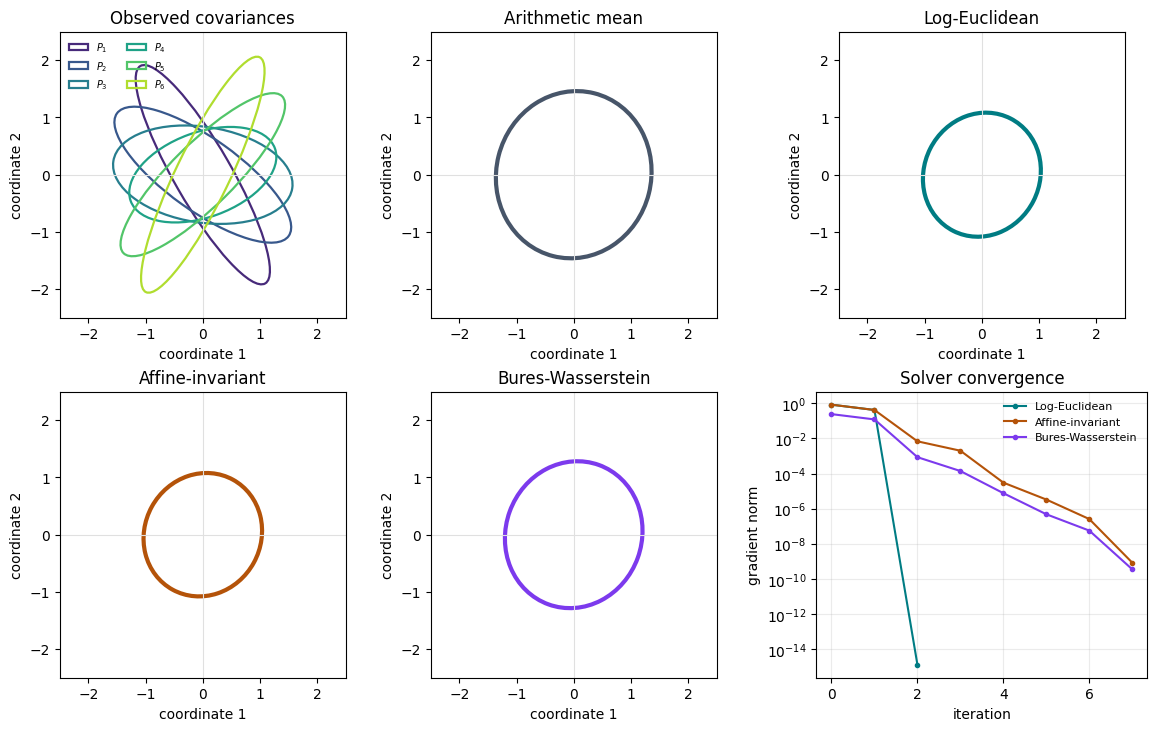

In [5]:
def draw_covariance(ax, matrix, color, label=None, alpha=1.0, linewidth=2.0):
    values, vectors = np.linalg.eigh(np.asarray(matrix))
    order = np.argsort(values)[::-1]
    values = values[order]
    vectors = vectors[:, order]
    angle = np.degrees(np.arctan2(vectors[1, 0], vectors[0, 0]))
    ellipse = Ellipse(
        (0.0, 0.0),
        width=2.0 * np.sqrt(values[0]),
        height=2.0 * np.sqrt(values[1]),
        angle=angle,
        facecolor="none",
        edgecolor=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
    )
    ax.add_patch(ellipse)


def format_covariance_axis(ax, title):
    ax.axhline(0.0, color="0.88", linewidth=0.8)
    ax.axvline(0.0, color="0.88", linewidth=0.8)
    ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), title=title)
    ax.set_aspect("equal")
    ax.set_xlabel("coordinate 1")
    ax.set_ylabel("coordinate 2")


fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.2), constrained_layout=True)
axes = axes.ravel()
sample_colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(samples)))
mean_colors = {
    "Log-Euclidean": "#007C83",
    "Affine-invariant": "#B45309",
    "Bures-Wasserstein": "#7C3AED",
}

for index, (matrix, color) in enumerate(zip(samples, sample_colors), start=1):
    draw_covariance(axes[0], matrix, color, label=f"$P_{index}$", linewidth=1.6)
format_covariance_axis(axes[0], "Observed covariances")
axes[0].legend(frameon=False, fontsize=7, ncol=2)

draw_covariance(axes[1], initial, "#475569", linewidth=3.0)
format_covariance_axis(axes[1], "Arithmetic mean")

for axis, name in zip(axes[2:5], geometries):
    draw_covariance(axis, estimates[name], mean_colors[name], linewidth=3.0)
    format_covariance_axis(axis, name)

for name, history in histories.items():
    gradient_norms = np.maximum([entry.gradnorm for entry in history], 1e-16)
    axes[5].semilogy(
        np.arange(len(history)),
        gradient_norms,
        marker="o",
        markersize=3,
        color=mean_colors[name],
        label=name,
    )
axes[5].set(
    title="Solver convergence",
    xlabel="iteration",
    ylabel="gradient norm",
)
axes[5].grid(alpha=0.25)
axes[5].legend(frameon=False, fontsize=8)

plt.show()

## Interpretation

There is no geometry-independent answer to the averaging problem. A useful
choice depends on which transformations and physical interpretation should be
respected:

- Use the log-Euclidean metric for a computationally simple flat model in
  logarithmic coordinates.
- Use the affine-invariant metric when invariance under $P\mapsto APA^\top$ for
  invertible $A$ is central.
- Use the Bures-Wasserstein metric when covariances represent Gaussian spread
  and optimal transport is the intended comparison.

Changing `samples` is enough to repeat the comparison in higher dimensions;
only the ellipse visualization is specific to $\operatorname{SPD}(2)$.